# Exploratory Data Analysis (EDA)
## Bengaluru House Price Prediction

### Objective
To explore and analyze the Bengaluru housing dataset, understand key factors
affecting house prices, detect outliers, and prepare insights for regression modeling.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [ ]:

df = pd.read_csv(r"C:\Users\Sam\Desktop\House_Price_Prediction\data\Bengaluru_House_Data.csv")
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [8]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


The dataset contains 13,320 records and 9 features including both numerical
and categorical variables related to housing attributes.


In [9]:
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Missing values are present in columns such as `bath`, `balcony`, and `society`.
These will be handled during data preprocessing.


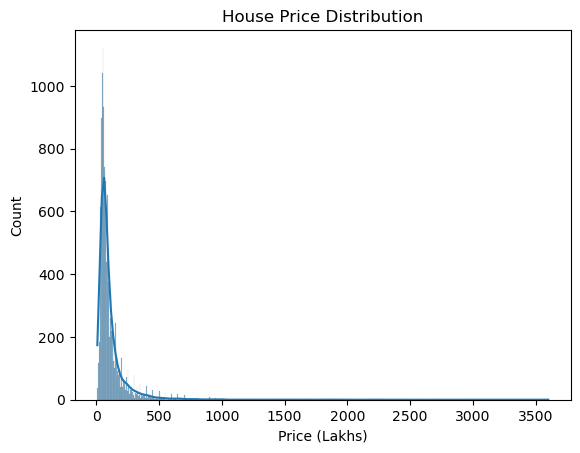

In [12]:
sns.histplot(df['price'], kde=True)
plt.xlabel("Price (Lakhs)")
plt.title("House Price Distribution")
plt.show()


House prices are right-skewed, indicating the presence of high-value properties
and potential outliers.


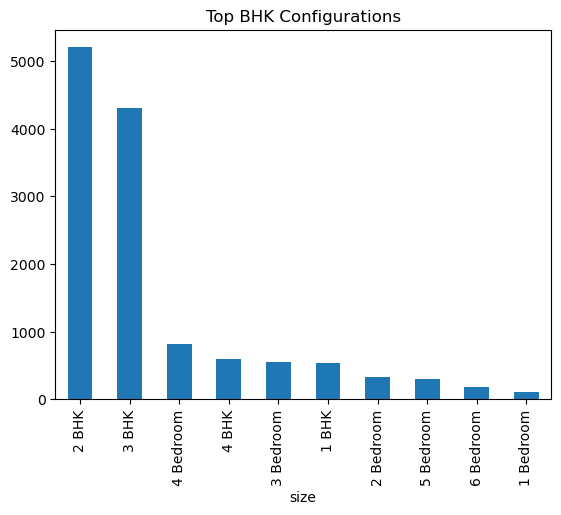

In [13]:
df['size'].value_counts().head(10).plot(kind='bar')
plt.title("Top BHK Configurations")
plt.show()


2 BHK and 3 BHK houses are the most common configurations in Bengaluru.


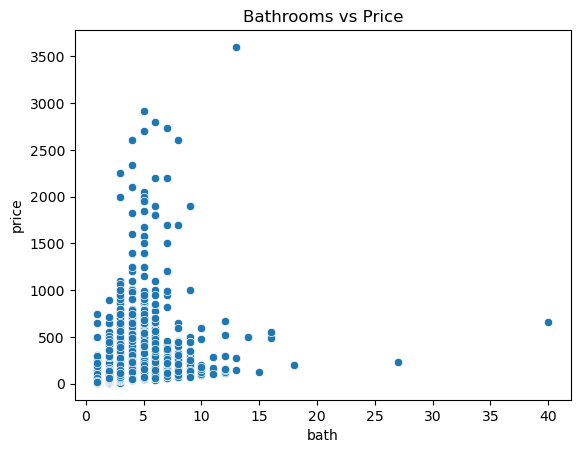

In [14]:
sns.scatterplot(x='bath', y='price', data=df)
plt.title("Bathrooms vs Price")
plt.show()


House prices generally increase with the number of bathrooms.


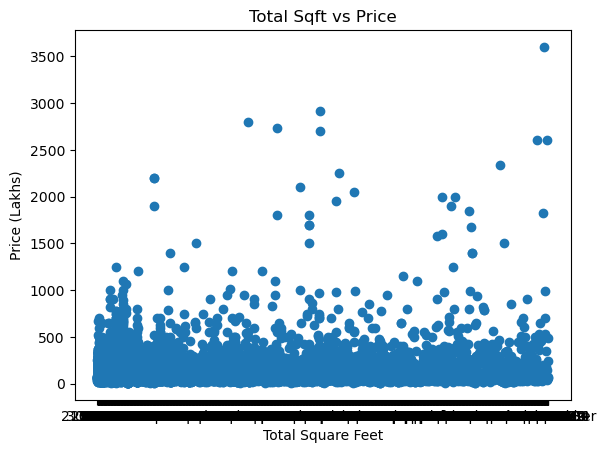

In [15]:
plt.scatter(df['total_sqft'], df['price'])
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")
plt.title("Total Sqft vs Price")
plt.show()


Larger properties tend to have higher prices, though extreme outliers are present.


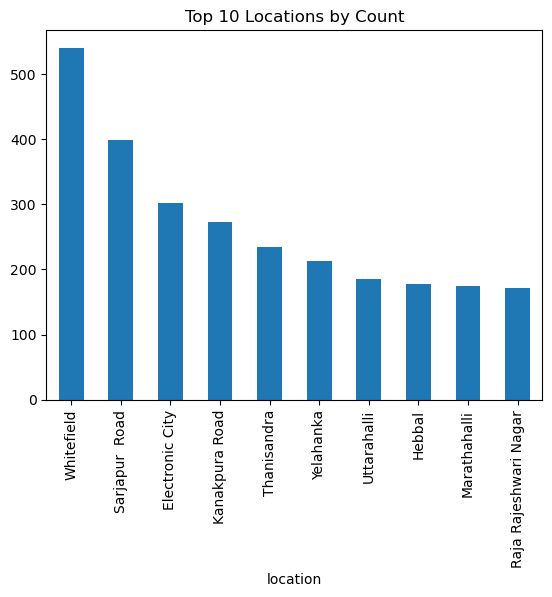

In [16]:
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Locations by Count")
plt.show()


In [17]:
df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)


location
Cubbon Road            1900.000000
Ashok Nagar            1486.000000
Defence Colony         1167.714286
Yemlur                 1093.388889
Church Street          1068.000000
D Souza Layout         1015.000000
Sadashiva Nagar        1011.100000
Sindhi Colony           988.000000
Srinivas Colony         922.000000
5th Block Jayanagar     905.000000
Name: price, dtype: float64

Location has a significant impact on housing prices in Bengaluru.


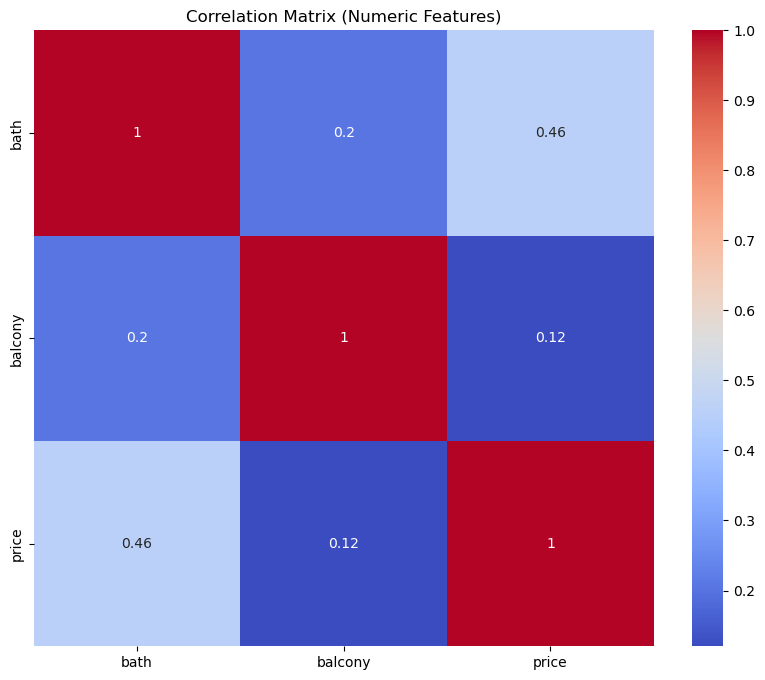

In [21]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


Correlation analysis was performed only on numerical features.
Total square feet, number of bathrooms, and balconies show strong
positive correlation with house prices.


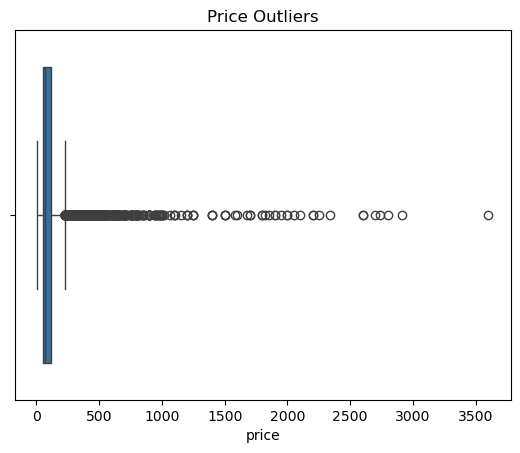

In [22]:
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()


Significant outliers are present in house prices, which justifies the need
for outlier removal during model training.


## EDA Summary

- House prices are right-skewed with significant outliers.
- Location, total square feet, and number of bathrooms strongly influence prices.
- Most houses are 2–3 BHK configurations.
- Outlier treatment and feature engineering are necessary for accurate prediction.
